In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from numpy import nan
from pathlib import Path
from chemont import ChemontDict, format_chemont_tree

from config import DATA_DIR, TRAINING_DIR

# 1) Load data

In [6]:
df = pd.read_csv(Path(DATA_DIR, TRAINING_DIR, "MSG_w_chemont.tsv"), sep="\t")
df = df[["identifier", "inchikey", "chemont_tree"]]
format_chemont_tree(df)


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166479 entries, 0 to 166478
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   identifier    166479 non-null  object
 1   inchikey      166479 non-null  object
 2   chemont_tree  164941 non-null  object
dtypes: object(3)
memory usage: 3.8+ MB


# 2) Translate ChemONT IDs to chemical hierarchy groups

In [4]:
chemont_d = ChemontDict(Path(DATA_DIR, "chemont_dictionary.tsv"))

In [7]:
chemical_levels = {
    "superclass": 0,
    "subclass": 1,
    "level3": 2,
    "level4": 3,
    "level5": 4,
}

data_df = df.copy()

for name in chemical_levels.keys():
    data_df[name] = nan
    data_df[name] = data_df[name].astype(object)

In [8]:
data_df["chemont_tree"] = data_df[data_df["chemont_tree"].notnull()]["chemont_tree"].apply(chemont_d.get_names_of_tree)
for i, row in data_df[data_df["chemont_tree"].notna()].iterrows():
    for name, pos in chemical_levels.items():
        data_df.at[i, name] = row["chemont_tree"][pos]

data_df.drop("chemont_tree", axis=1, inplace=True)
data_df.info()
data_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166479 entries, 0 to 166478
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   identifier  166479 non-null  object
 1   inchikey    166479 non-null  object
 2   superclass  164941 non-null  object
 3   subclass    164941 non-null  object
 4   level3      163135 non-null  object
 5   level4      163135 non-null  object
 6   level5      164941 non-null  object
dtypes: object(7)
memory usage: 8.9+ MB


,identifier,inchikey,superclass,subclass,level3,level4,level5
0,MassSpecGymID0000001,VFMQMACUYWGDOJ,Organic compounds,Phenylpropanoids and polyketides,Kavalactones,Kavalactones,Kavalactones
1,MassSpecGymID0000002,VFMQMACUYWGDOJ,Organic compounds,Phenylpropanoids and polyketides,Kavalactones,Kavalactones,Kavalactones
2,MassSpecGymID0000003,VFMQMACUYWGDOJ,Organic compounds,Phenylpropanoids and polyketides,Kavalactones,Kavalactones,Kavalactones
3,MassSpecGymID0000004,VFMQMACUYWGDOJ,Organic compounds,Phenylpropanoids and polyketides,Kavalactones,Kavalactones,Kavalactones
4,MassSpecGymID0000005,VFMQMACUYWGDOJ,Organic compounds,Phenylpropanoids and polyketides,Kavalactones,Kavalactones,Kavalactones
...,...,...,...,...,...,...,...
166474,MassSpecGymID0414136,OZRNSSUDZOLUSN,Organic compounds,Organoheterocyclic compounds,Pteridines and derivatives,Pterins and derivatives,Dihydrofolic acids and derivatives
166475,MassSpecGymID0414138,CJBDUOMQLFKVQC,Organic compounds,Phenylpropanoids and polyketides,Phenylpropanoic acids,Phenylpropanoic acids,Phenylpropanoic acids
166476,MassSpecGymID0414147,YOIFSTUAGLOWPB,Organic compounds,Organoheterocyclic compounds,Azoles,Imidazoles,N-substituted imidazoles
166477,MassSpecGymID0414148,UNMZJSVCTCKOEC,Organic compounds,Phenylpropanoids and polyketides,Flavonoids,Flavonoid glycosides,Flavonoid-7-O-glycosides


# 3) Generate plots

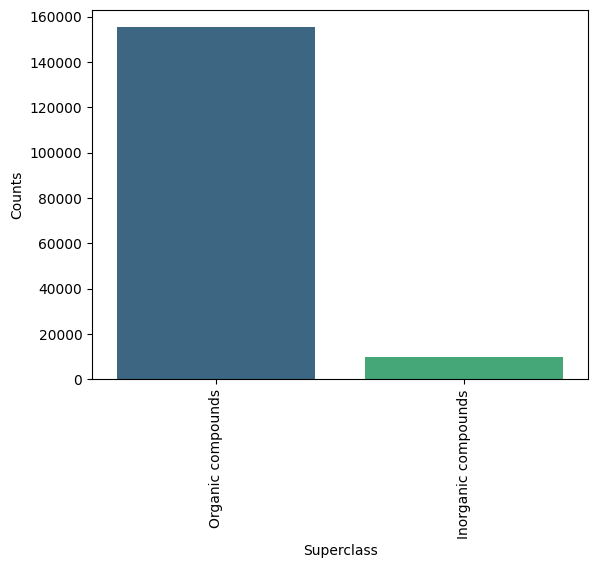

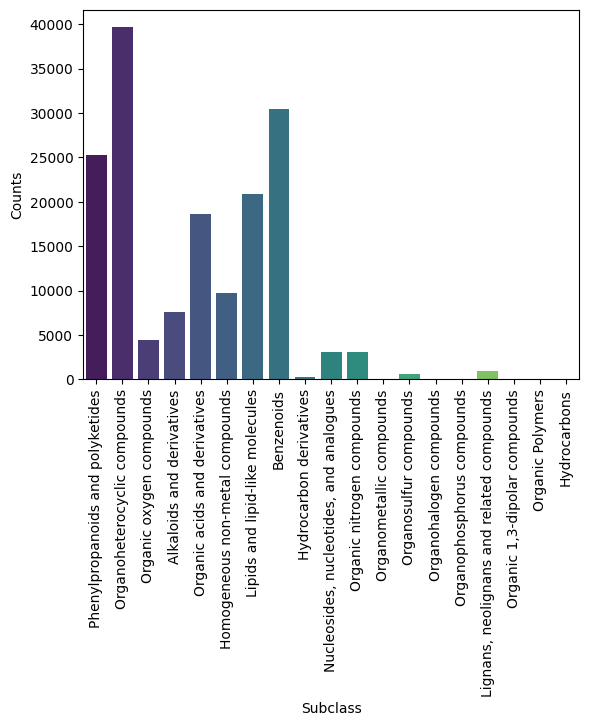

In [14]:
for name in list(chemical_levels.keys())[:2]:
    aux_df = pd.DataFrame()
    aux_df[name] = data_df[name].dropna().unique()
    aux_df = aux_df.join(data_df[name].value_counts(), on=name)

    p = sns.barplot(data=aux_df, x=name, y="count", hue=name, palette='viridis', legend=False)
    plt.xlabel(name.capitalize())
    plt.xticks(rotation=90)
    plt.ylabel("Counts")
    plt.show()

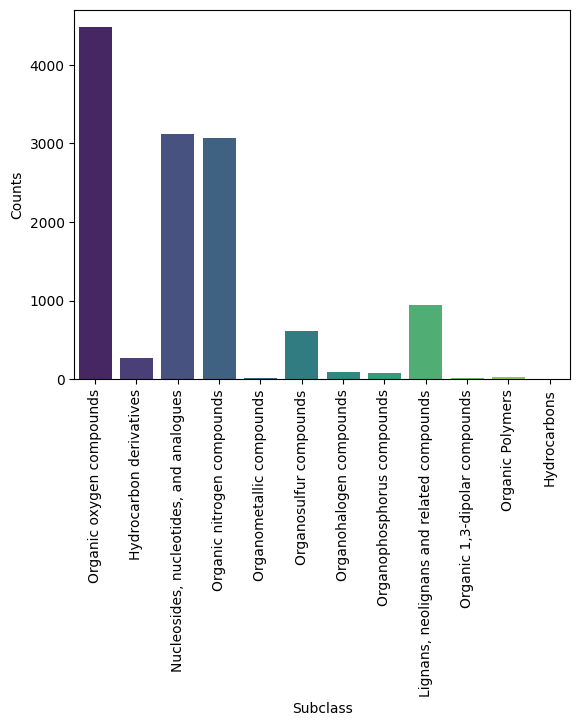

In [15]:
name = "subclass"

aux_df = pd.DataFrame()
aux_df[name] = data_df[name].dropna().unique()
aux_df = aux_df.join(data_df[name].value_counts(), on=name)

aux_df.where(aux_df["count"] < 5000, nan, inplace=True)
aux_df.dropna(inplace=True)

p = sns.barplot(data=aux_df, x=name, y="count", hue=name, palette='viridis', legend=False)
plt.xlabel(name.capitalize())
plt.xticks(rotation=90)
plt.ylabel("Counts")
plt.show()